# 🎙️ Voice Deepfake Detection

## 0 · Imports & Config

In [10]:
!pip install datasets

In [11]:
# Install any packages not pre-installed on Kaggle
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import lightgbm
    print(f'lightgbm {lightgbm.__version__} already installed ✓')
except ImportError:
    pip_install('lightgbm')
    print('lightgbm installed ✓')

try:
    import xgboost
    print(f'xgboost {xgboost.__version__} already installed ✓')
except ImportError:
    pip_install('xgboost')
    print('xgboost installed ✓')

print('Package check complete ✓')

lightgbm 4.6.0 already installed ✓
xgboost 3.2.0 already installed ✓
Package check complete ✓


In [12]:
import os, gc, time, joblib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt          # Kaggle renders inline — no Agg backend needed
import seaborn as sns
import requests
from pathlib import Path
from collections import defaultdict

# Sklearn
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier,
    StackingClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, average_precision_score
)

import lightgbm as lgb
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Kaggle-compatible paths ──────────────────────────────────────────────
# Kaggle working dir is /kaggle/working
KAGGLE_INPUT = Path('/kaggle/input')
IS_KAGGLE    = KAGGLE_INPUT.exists()
WORK_DIR     = Path('/kaggle/working') if IS_KAGGLE else Path('.')
MODEL_DIR    = WORK_DIR / 'models'
PLOTS_DIR    = WORK_DIR / 'plots'
MODEL_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f'Running on Kaggle : {IS_KAGGLE}')
print(f'Device            : {DEVICE}')
print(f'Torch             : {torch.__version__}')
print(f'Working dir       : {WORK_DIR}')
print('Ready ✓')

Running on Kaggle : True
Device            : cpu
Torch             : 2.10.0+cpu
Working dir       : /kaggle/working
Ready ✓


## 1 · Download & Load Dataset

In [13]:
import pandas as pd

# The direct URL to the metadata CSV on Hugging Face
csv_url = "https://huggingface.co/datasets/gayaneyemishyan/deepfake-voice-detection-dataset/resolve/main/voice_deepfake_detection.csv"

print("Reading CSV directly from Hugging Face...")

# Use low_memory=False to handle mixed types gracefully
try:
    # We use nrows=100000 just to test first, remove it to load the whole thing
    df_raw = pd.read_csv(csv_url, low_memory=False) 
    print(f"Successfully loaded! Total rows: {len(df_raw):,}")
    
    # Check the columns
    print("\nColumns found:", df_raw.columns.tolist())
    
    # Preview the data
    display(df_raw.head())
    
    if 'label' in df_raw.columns:
        print("\nLabel Distribution:")
        print(df_raw['label'].value_counts())

except Exception as e:
    print(f"Direct load failed: {e}")

Reading CSV directly from Hugging Face...
Successfully loaded! Total rows: 1,156,453

Columns found: ['file_name', 'label', 'source', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_flatness_mean', 'spectral_flatness_std', 'spectral_contrast_1_mean', 'spectral_contrast_1_std', 'spectral_contrast_2_mean', 'spectral_contrast_2_std', 'spectral_contrast_3_mean', 'spectral_contrast_3_std', 'spectral_contrast_4_mean', 'spectral_contrast_4_std', 'spectral_contrast_5_mean', 'spectral_contrast_5_std', 'spectral_contrast_6_mean', 'spectral_contrast_6_std', 'spectral_contrast_7_mean', 'spectral_contrast_7_std', 'chroma_1_mean', 'chroma_1_std', 'chroma_2_mean', 'chroma_2_std', 'chroma_3_mean', 'chroma_3_std', 'chroma_4_mean', 'chroma_4_std', 'chroma_5_mean', 'chroma_5_std', 'chroma_6_mean', 'chroma_6_std', 'chroma_7_mean', 'chroma_7_std', 'chroma_8_mean', 'chroma_8_std', 'chroma_9_mea

,file_name,label,source,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,spectral_flatness_mean,...,lfcc_12,lfcc_13,lfcc_14,lfcc_15,lfcc_16,lfcc_17,lfcc_18,lfcc_19,lfcc_20,split
0,LA_E_1000048.flac,1,asvspoof2021_LA,1913.769654,1062.510477,1513.346862,470.450964,3562.988281,1443.219739,0.016077,...,0.489605,-0.573446,0.249675,0.526508,0.235258,-0.660863,-0.131137,-0.188571,-0.082341,NaN
1,LA_E_1000166.flac,1,asvspoof2021_LA,1972.755383,1253.627205,1466.925225,509.449771,3468.569015,1815.964121,0.032998,...,1.426983,0.163533,0.968036,-0.839261,-0.070096,-0.652173,-0.076106,-0.345391,0.092194,NaN
2,LA_E_1000174.flac,1,asvspoof2021_LA,1857.505819,901.972487,1648.417595,585.671286,3642.045455,1798.681214,0.035025,...,0.127916,0.241546,-0.364184,-0.597517,-0.318421,0.121812,0.229041,0.013706,-0.078953,NaN
3,LA_E_1000200.flac,1,asvspoof2021_LA,1047.047908,394.610110,1010.693287,249.505670,2142.083333,810.662680,0.001276,...,-0.991688,-0.183928,1.112558,0.413985,-0.682733,-0.296969,0.514358,0.105726,-0.590208,NaN
4,LA_E_1000345.flac,1,asvspoof2021_LA,1532.132423,1030.044883,1681.247861,379.976277,3246.345766,1359.116237,0.012007,...,0.847960,-0.428972,0.568682,-0.161738,0.078663,-0.161034,0.180701,-0.081008,-0.014093,NaN



Label Distribution:
label
1    991408
0    165045
Name: count, dtype: int64


## 2 · Exploratory Data Analysis

In [14]:
print('=== dtypes & nulls ===')
info_df = pd.DataFrame({
    'dtype':  df_raw.dtypes,
    'nulls':  df_raw.isnull().sum(),
    'null_%': (df_raw.isnull().mean() * 100).round(2),
    'unique': df_raw.nunique()
})
print(info_df[info_df['nulls'] > 0].to_string() if info_df['nulls'].sum() > 0
      else 'No null values found ✓')
print(f'\nTotal rows : {len(df_raw):,}')
print(f'Total cols : {df_raw.shape[1]}')
print('\nLabel distribution:')
print(df_raw['label'].value_counts())

=== dtypes & nulls ===
                dtype    nulls  null_%   unique
source         object    31779    2.75        2
gfcc_1_mean   float64        1    0.00  1156452
gfcc_1_std    float64        1    0.00  1156452
gfcc_2_mean   float64        1    0.00  1156452
gfcc_2_std    float64        1    0.00  1156452
gfcc_3_mean   float64        1    0.00  1156452
gfcc_3_std    float64        1    0.00  1156452
gfcc_4_mean   float64        1    0.00  1156452
gfcc_4_std    float64        1    0.00  1156452
gfcc_5_mean   float64        1    0.00  1156452
gfcc_5_std    float64        1    0.00  1156452
gfcc_6_mean   float64        1    0.00  1156452
gfcc_6_std    float64        1    0.00  1156452
gfcc_7_mean   float64        1    0.00  1156452
gfcc_7_std    float64        1    0.00  1156452
gfcc_8_mean   float64        1    0.00  1156452
gfcc_8_std    float64        1    0.00  1156452
gfcc_9_mean   float64        1    0.00  1156452
gfcc_9_std    float64        1    0.00  1156452
gfcc_10_mean  flo

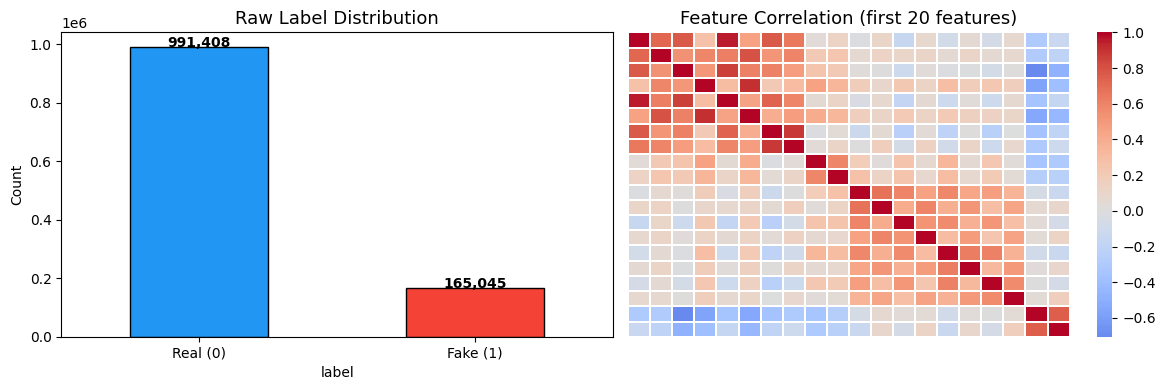

EDA plots saved ✓


In [15]:
# ── Plot class balance ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df_raw['label'].value_counts()
vc.plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336'], edgecolor='black')
axes[0].set_title('Raw Label Distribution', fontsize=13)
axes[0].set_xticklabels(['Real (0)', 'Fake (1)'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(vc):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Feature correlation heatmap (sample 20 features for readability)
non_feat = ['file_name', 'label', 'source', 'split']
feat_preview = [c for c in df_raw.columns if c not in non_feat][:20]
corr = df_raw[feat_preview].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0,
            linewidths=0.3, xticklabels=False, yticklabels=False)
axes[1].set_title('Feature Correlation (first 20 features)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA plots saved ✓')

## 3 · Data Cleaning

In [16]:
df = df_raw.copy()

# ── 3.1 Drop metadata / leakage columns ────────────────────────────────
drop_cols = [c for c in ['split', 'file_name', 'source'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'Dropped metadata columns: {drop_cols}')

# ── 3.2 Identify feature columns ───────────────────────────────────────
NON_FEAT = ['label']
feat_cols = [c for c in df.columns if c not in NON_FEAT]
print(f'Feature columns: {len(feat_cols)}')

# ── 3.3 Cast to float32 ────────────────────────────────────────────────
for c in feat_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')
df['label'] = df['label'].astype('int8')

# ── 3.4 Handle missing values ──────────────────────────────────────────
null_before = df[feat_cols].isnull().sum().sum()
if null_before > 0:
    print(f'Null values before: {null_before:,}')
    # Fill with column median (robust to outliers)
    col_medians = df[feat_cols].median()
    df[feat_cols] = df[feat_cols].fillna(col_medians)
    null_after = df[feat_cols].isnull().sum().sum()
    print(f'Null values after median-fill: {null_after:,}')
else:
    print('No missing values ✓')

# ── 3.5 Drop duplicate rows ────────────────────────────────────────────
dups = df.duplicated().sum()
if dups > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Removed {dups:,} duplicate rows')
else:
    print('No duplicate rows ✓')

# ── 3.6 Drop constant / near-zero variance features ────────────────────
std = df[feat_cols].std()
const_cols = std[std < 1e-8].index.tolist()
if const_cols:
    df.drop(columns=const_cols, inplace=True)
    feat_cols = [c for c in feat_cols if c not in const_cols]
    print(f'Removed {len(const_cols)} constant features')
else:
    print('No constant features ✓')


print(f'\nClean dataset shape: {df.shape}')
print(f'Feature count      : {len(feat_cols)}')

Dropped metadata columns: ['split', 'file_name', 'source']
Feature columns: 227
Null values before: 40
Null values after median-fill: 0
No duplicate rows ✓
No constant features ✓

Clean dataset shape: (1156453, 228)
Feature count      : 227


## 4 · Stratified Train / Validation / Test Split (80 / 10 / 10)

In [17]:
# ── 4.1 First split: 90% train_val | 10% test ──────────────────────────
train_val_df, test_df = train_test_split(
    df, test_size=0.10, random_state=RANDOM_STATE, stratify=df['label']
)

# ── 4.2 Second split: 88.9% train | 11.1% val (≈80/10 of full) ─────────
train_df, val_df = train_test_split(
    train_val_df, test_size=0.1111, random_state=RANDOM_STATE,
    stratify=train_val_df['label']
)

print('=== Split Sizes ===')
for name, part in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    real = (part['label'] == 0).sum()
    fake = (part['label'] == 1).sum()
    print(f'{name:5s}: {len(part):7,}  |  Real {real:6,} ({real/len(part):.1%})  Fake {fake:6,} ({fake/len(part):.1%})')

# ── 4.3 Balance ONLY the training set with undersampling ────────────────
real_train = train_df[train_df['label'] == 0]
fake_train = train_df[train_df['label'] == 1]
minority   = min(len(real_train), len(fake_train))

real_bal = resample(real_train, replace=False, n_samples=minority, random_state=RANDOM_STATE)
fake_bal = resample(fake_train, replace=False, n_samples=minority, random_state=RANDOM_STATE)
balanced_train = pd.concat([real_bal, fake_bal]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Balanced train: {len(balanced_train):,}  (Real {minority:,}  |  Fake {minority:,})')

# ── 4.4 Extract arrays ──────────────────────────────────────────────────
X_train = balanced_train[feat_cols].values.astype('float32')
y_train = balanced_train['label'].values.astype('int32')

X_val   = val_df[feat_cols].values.astype('float32')
y_val   = val_df['label'].values.astype('int32')

X_test  = test_df[feat_cols].values.astype('float32')
y_test  = test_df['label'].values.astype('int32')

# ── 4.5 Clip outliers (fit on train only)  ─────────────────────────────
q01 = pd.DataFrame(X_train).quantile(0.01)
q99 = pd.DataFrame(X_train).quantile(0.99)
X_train = np.clip(X_train, q01.values, q99.values)
X_val   = np.clip(X_val,   q01.values, q99.values)
X_test  = np.clip(X_test,  q01.values, q99.values)
joblib.dump((q01.values, q99.values), MODEL_DIR / 'clip_bounds.pkl')
print('Clipped features to train [1%, 99%] range ✓')

# ── 4.6 Scale features (fit on train only) ─────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')
print('Scaler saved ✓')

# Cleanup
del train_val_df, train_df, val_df, balanced_train, real_train, fake_train
gc.collect()
print('Memory cleaned ✓')

=== Split Sizes ===
Train: 925,173  |  Real 132,037 (14.3%)  Fake 793,136 (85.7%)
Val  : 115,634  |  Real 16,503 (14.3%)  Fake 99,131 (85.7%)
Test : 115,646  |  Real 16,505 (14.3%)  Fake 99,141 (85.7%)
Balanced train: 264,074  (Real 132,037  |  Fake 132,037)
Clipped features to train [1%, 99%] range ✓
Scaler saved ✓
Memory cleaned ✓


## 5 · Helper: Evaluation Utilities

In [18]:
# Leaderboard dict – filled by each model block
leaderboard = {}

def evaluate_model(name, y_true, y_pred, y_prob):
    """Compute, print and store metrics. Returns metrics dict."""
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    pr   = average_precision_score(y_true, y_prob)
    rep  = classification_report(y_true, y_pred, target_names=['Real','Fake'])

    metrics = dict(Accuracy=acc, F1=f1, AUC_ROC=auc, AUC_PR=pr)
    leaderboard[name] = metrics

    print(f'\n══ {name} ══')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    print(rep)
    return metrics


def plot_roc(ax, y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, lw=1.8, label=f'{label} (AUC={auc:.3f})')


def optimal_threshold(y_true, y_prob):
    """Find threshold maximising F1 on the provided split."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1s)
    return float(thr[best_idx]) if best_idx < len(thr) else 0.5

print('Utilities ready ✓')

Utilities ready ✓


## 6 · Model Training

We train 8 models plus a stacking ensemble. Each is evaluated on **validation set** for tuning; final scores are reported on the **test set**.

| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Strong baseline, fast |
| 2 | Gaussian Naive Bayes | Probabilistic baseline |
| 3 | K-Nearest Neighbours | Non-parametric |
| 4 | Random Forest | Ensemble of trees |
| 5 | Extra Trees | Randomised forest |
| 6 | XGBoost | Gradient boosting |
| 7 | LightGBM | Fast gradient boosting |
| 8 | MLP (PyTorch) | Deep neural network |
| 9 | Stacking Ensemble | Meta-learner over best models |

### 6.1 — Logistic Regression

In [19]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0, solver='saga',
                        n_jobs=-1, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
lr_prob = lr.predict_proba(X_val_s)[:, 1]
lr_pred = lr.predict(X_val_s)
evaluate_model('LogisticRegression (val)', y_val, lr_pred, lr_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
joblib.dump(lr, MODEL_DIR / 'logistic_regression.pkl')


══ LogisticRegression (val) ══
  Accuracy    : 0.8237
  F1          : 0.8886
  AUC_ROC     : 0.9065
  AUC_PR      : 0.9814
              precision    recall  f1-score   support

        Real       0.44      0.84      0.58     16503
        Fake       0.97      0.82      0.89     99131

    accuracy                           0.82    115634
   macro avg       0.70      0.83      0.73    115634
weighted avg       0.89      0.82      0.84    115634

  Training time: 71.1s


['/kaggle/working/models/logistic_regression.pkl']

### 6.2 — Gaussian Naive Bayes

In [20]:
t0 = time.time()
gnb = GaussianNB()
gnb.fit(X_train_s, y_train)
gnb_prob = gnb.predict_proba(X_val_s)[:, 1]
gnb_pred = gnb.predict(X_val_s)
evaluate_model('GaussianNB (val)', y_val, gnb_pred, gnb_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
joblib.dump(gnb, MODEL_DIR / 'naive_bayes.pkl')


══ GaussianNB (val) ══
  Accuracy    : 0.6861
  F1          : 0.7872
  AUC_ROC     : 0.7645
  AUC_PR      : 0.9410
              precision    recall  f1-score   support

        Real       0.28      0.74      0.40     16503
        Fake       0.94      0.68      0.79     99131

    accuracy                           0.69    115634
   macro avg       0.61      0.71      0.59    115634
weighted avg       0.84      0.69      0.73    115634

  Training time: 2.1s


['/kaggle/working/models/naive_bayes.pkl']

### 6.3 — K-Nearest Neighbours

In [21]:
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
knn.fit(X_train_s, y_train)
knn_prob = knn.predict_proba(X_val_s)[:, 1]
knn_pred = knn.predict(X_val_s)
evaluate_model('KNN (val)', y_val, knn_pred, knn_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
joblib.dump(knn, MODEL_DIR / 'knn.pkl')


══ KNN (val) ══
  Accuracy    : 0.7715
  F1          : 0.8476
  AUC_ROC     : 0.9516
  AUC_PR      : 0.9885
              precision    recall  f1-score   support

        Real       0.38      0.95      0.54     16503
        Fake       0.99      0.74      0.85     99131

    accuracy                           0.77    115634
   macro avg       0.68      0.85      0.70    115634
weighted avg       0.90      0.77      0.80    115634

  Training time: 539.5s


['/kaggle/working/models/knn.pkl']

### 6.4 — Random Forest

In [22]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE,
    class_weight='balanced'
)
rf.fit(X_train_s, y_train)
rf_prob = rf.predict_proba(X_val_s)[:, 1]
rf_pred = rf.predict(X_val_s)
evaluate_model('RandomForest (val)', y_val, rf_pred, rf_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
joblib.dump(rf, MODEL_DIR / 'random_forest.pkl')


══ RandomForest (val) ══
  Accuracy    : 0.9042
  F1          : 0.9417
  AUC_ROC     : 0.9698
  AUC_PR      : 0.9945
              precision    recall  f1-score   support

        Real       0.61      0.91      0.73     16503
        Fake       0.98      0.90      0.94     99131

    accuracy                           0.90    115634
   macro avg       0.80      0.91      0.84    115634
weighted avg       0.93      0.90      0.91    115634

  Training time: 1272.8s


['/kaggle/working/models/random_forest.pkl']

### 6.5 — Extra Trees

In [23]:
t0 = time.time()
et = ExtraTreesClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE, class_weight='balanced'
)
et.fit(X_train_s, y_train)
et_prob = et.predict_proba(X_val_s)[:, 1]
et_pred = et.predict(X_val_s)
evaluate_model('ExtraTrees (val)', y_val, et_pred, et_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
joblib.dump(et, MODEL_DIR / 'extra_trees.pkl')


══ ExtraTrees (val) ══
  Accuracy    : 0.8951
  F1          : 0.9358
  AUC_ROC     : 0.9696
  AUC_PR      : 0.9945
              precision    recall  f1-score   support

        Real       0.58      0.91      0.71     16503
        Fake       0.98      0.89      0.94     99131

    accuracy                           0.90    115634
   macro avg       0.78      0.90      0.82    115634
weighted avg       0.93      0.90      0.90    115634

  Training time: 294.4s


['/kaggle/working/models/extra_trees.pkl']

### 6.6 — XGBoost

In [24]:
orig_labels = df['label'].values  # df still exists at this point
scale_pos_weight = (orig_labels == 0).sum() / (orig_labels == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

scale_pos_weight: 0.166


In [25]:
t0 = time.time()

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',     # fast histogram method
    early_stopping_rounds=30,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)
xgb_clf.fit(
    X_train_s, y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=50
)
xgb_prob = xgb_clf.predict_proba(X_val_s)[:, 1]
xgb_pred = xgb_clf.predict(X_val_s)
evaluate_model('XGBoost (val)', y_val, xgb_pred, xgb_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
xgb_clf.save_model(str(MODEL_DIR / 'xgboost.json'))

[0]	validation_0-logloss:1.40862
[50]	validation_0-logloss:0.95306
[100]	validation_0-logloss:0.79618
[150]	validation_0-logloss:0.70346
[200]	validation_0-logloss:0.63578
[250]	validation_0-logloss:0.58408
[300]	validation_0-logloss:0.54550
[350]	validation_0-logloss:0.51169
[400]	validation_0-logloss:0.48376
[450]	validation_0-logloss:0.45821
[499]	validation_0-logloss:0.43878

══ XGBoost (val) ══
  Accuracy    : 0.7864
  F1          : 0.8578
  AUC_ROC     : 0.9805
  AUC_PR      : 0.9967
              precision    recall  f1-score   support

        Real       0.40      0.99      0.57     16503
        Fake       1.00      0.75      0.86     99131

    accuracy                           0.79    115634
   macro avg       0.70      0.87      0.71    115634
weighted avg       0.91      0.79      0.82    115634

  Training time: 115.9s


### 6.7 — LightGBM

In [26]:
t0 = time.time()
lgb_train_data = lgb.Dataset(X_train_s, label=y_train)
lgb_val_data   = lgb.Dataset(X_val_s,   label=y_val, reference=lgb_train_data)

lgb_params = dict(
    objective='binary',
    metric='binary_logloss',
    boosting_type='gbdt',
    num_leaves=63,
    max_depth=-1,
    learning_rate=0.05,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_child_samples=20,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    verbose=-1,
    random_state=RANDOM_STATE
)

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=50)
]
lgb_model = lgb.train(
    lgb_params,
    lgb_train_data,
    num_boost_round=500,
    valid_sets=[lgb_val_data],
    callbacks=callbacks
)
lgb_prob = lgb_model.predict(X_val_s)
lgb_pred = (lgb_prob >= 0.5).astype(int)
evaluate_model('LightGBM (val)', y_val, lgb_pred, lgb_prob)
print(f'  Training time: {time.time()-t0:.1f}s')
lgb_model.save_model(str(MODEL_DIR / 'lightgbm.txt'))


══ LightGBM (val) ══
  Accuracy    : 0.3919
  F1          : 0.4532
  AUC_ROC     : 0.7970
  AUC_PR      : 0.9554
              precision    recall  f1-score   support

        Real       0.19      0.98      0.32     16503
        Fake       0.99      0.29      0.45     99131

    accuracy                           0.39    115634
   macro avg       0.59      0.64      0.38    115634
weighted avg       0.87      0.39      0.43    115634

  Training time: 18.7s


### 6.8 — MLP (PyTorch) with Early Stopping

Epoch   1/60  train_loss=0.1309  val_loss=0.0857  lr=9.97e-04
Epoch   2/60  train_loss=0.0661  val_loss=0.0579  lr=9.89e-04
Epoch   3/60  train_loss=0.0510  val_loss=0.0443  lr=9.76e-04
Epoch   4/60  train_loss=0.0429  val_loss=0.0437  lr=9.57e-04
Epoch   5/60  train_loss=0.0379  val_loss=0.0433  lr=9.33e-04
Epoch   6/60  train_loss=0.0342  val_loss=0.0354  lr=9.05e-04
Epoch   7/60  train_loss=0.0310  val_loss=0.0323  lr=8.72e-04
Epoch   8/60  train_loss=0.0280  val_loss=0.0311  lr=8.35e-04
Epoch   9/60  train_loss=0.0257  val_loss=0.0277  lr=7.94e-04
Epoch  10/60  train_loss=0.0243  val_loss=0.0260  lr=7.50e-04
Epoch  12/60  train_loss=0.0211  val_loss=0.0238  lr=6.55e-04
Epoch  15/60  train_loss=0.0173  val_loss=0.0216  lr=5.00e-04
Epoch  16/60  train_loss=0.0165  val_loss=0.0211  lr=4.48e-04
Epoch  17/60  train_loss=0.0153  val_loss=0.0203  lr=3.96e-04
Epoch  18/60  train_loss=0.0145  val_loss=0.0199  lr=3.45e-04
Epoch  19/60  train_loss=0.0137  val_loss=0.0179  lr=2.97e-04
Epoch  2

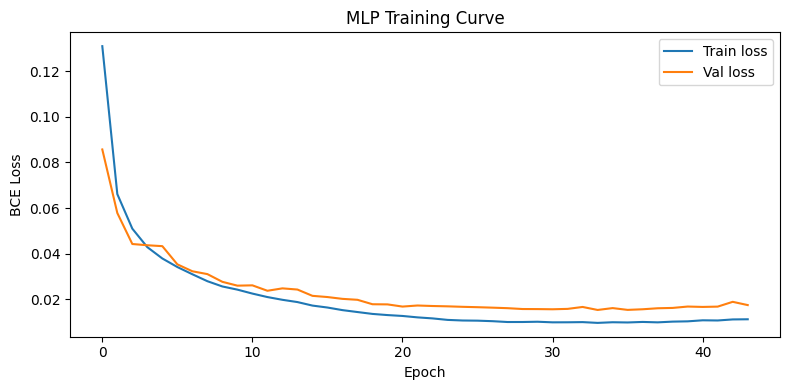

In [27]:
# ── Architecture ────────────────────────────────────────────────────────
class DeepfakeMLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=(512, 256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


# ── DataLoaders ─────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=2048, shuffle=False):
    Xt = torch.from_numpy(X).float()
    yt = torch.from_numpy(y).float()
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train_s, y_train, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val)

# ── Training loop ───────────────────────────────────────────────────────
t0 = time.time()
mlp = DeepfakeMLP(in_dim=X_train_s.shape[1]).to(DEVICE)

pos_weight = torch.tensor([
    (orig_labels == 0).sum() / (orig_labels == 1).sum()
], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

EPOCHS = 60
PATIENCE = 10
best_val_loss = float('inf')
patience_ctr  = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Train
    mlp.train()
    ep_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(mlp(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item() * len(Xb)
    train_loss = ep_loss / len(train_loader.dataset)

    # Validate
    mlp.eval()
    vl = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            vl += criterion(mlp(Xb), yb).item() * len(Xb)
    val_loss = vl / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mlp.state_dict(), MODEL_DIR / 'mlp_best.pt')
        patience_ctr = 0
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or patience_ctr == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

# Load best weights
mlp.load_state_dict(torch.load(MODEL_DIR / 'mlp_best.pt', map_location=DEVICE))
mlp.eval()

# Evaluate on val
with torch.no_grad():
    Xv_t = torch.from_numpy(X_val_s).float().to(DEVICE)
    logits = mlp(Xv_t).cpu().numpy()
mlp_prob = torch.sigmoid(torch.tensor(logits)).numpy()
mlp_pred = (mlp_prob >= 0.5).astype(int)
evaluate_model('MLP (val)', y_val, mlp_pred, mlp_prob)
print(f'  Training time: {time.time()-t0:.1f}s')

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('MLP Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mlp_training_curve.png', dpi=120)
plt.show()

## 7 · Validation Leaderboard


=== Validation Leaderboard (sorted by AUC-ROC) ===
                         Accuracy      F1 AUC_ROC  AUC_PR
MLP (val)                  0.9713  0.9830  0.9991  0.9998
XGBoost (val)              0.7864  0.8578  0.9805  0.9967
RandomForest (val)         0.9042  0.9417  0.9698  0.9945
ExtraTrees (val)           0.8951  0.9358  0.9696  0.9945
KNN (val)                  0.7715  0.8476  0.9516  0.9885
LogisticRegression (val)   0.8237  0.8886  0.9065  0.9814
LightGBM (val)             0.3919  0.4532  0.7970  0.9554
GaussianNB (val)           0.6861  0.7872  0.7645  0.9410


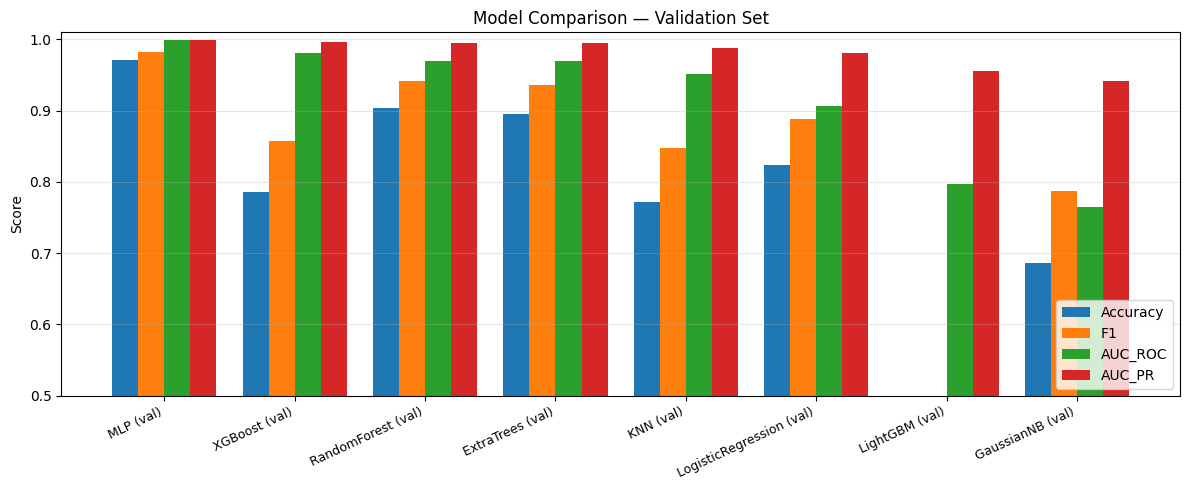


🏆 Best model on validation: MLP (val)


In [28]:
lb_df = pd.DataFrame(leaderboard).T.sort_values('AUC_ROC', ascending=False)
lb_df = lb_df.map(lambda x: f'{x:.4f}')
print('\n=== Validation Leaderboard (sorted by AUC-ROC) ===')
print(lb_df.to_string())

# Bar chart
lb_num = pd.DataFrame(leaderboard).T.sort_values('AUC_ROC', ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(lb_num))
w = 0.2
for i, col in enumerate(['Accuracy', 'F1', 'AUC_ROC', 'AUC_PR']):
    ax.bar(x + i*w, lb_num[col], width=w, label=col)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(lb_num.index, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.01)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Validation Set')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_comparison.png', dpi=120)
plt.show()

best_model_name = lb_num['AUC_ROC'].idxmax()
print(f'\n🏆 Best model on validation: {best_model_name}')

## 8 · ROC Curves — All Models on Validation Set

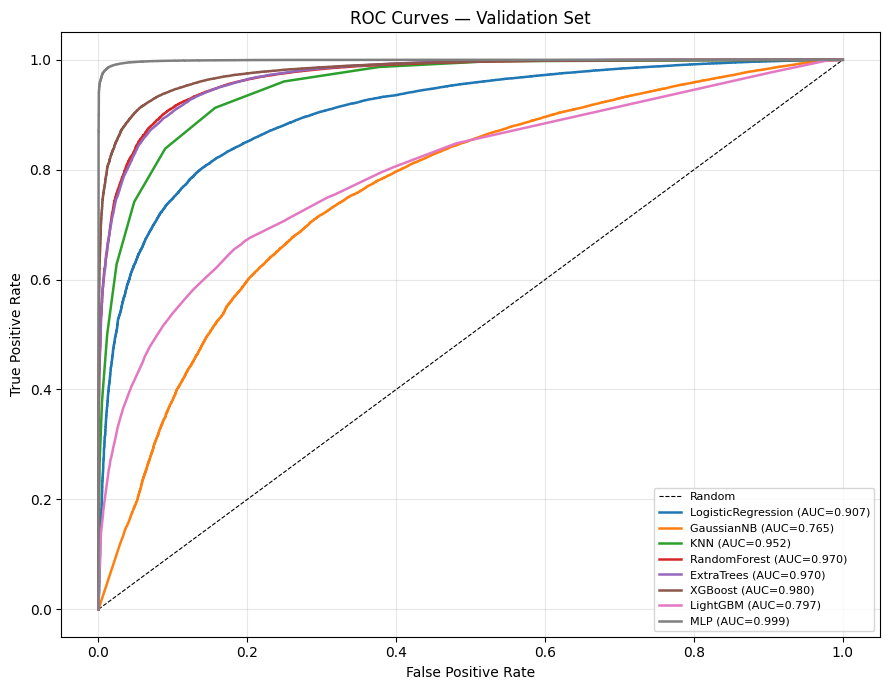

In [29]:
# Collect val probabilities
all_probs = {
    'LogisticRegression': lr_prob,
    'GaussianNB':         gnb_prob,
    'KNN':                knn_prob,
    'RandomForest':       rf_prob,
    'ExtraTrees':         et_prob,
    'XGBoost':            xgb_prob,
    'LightGBM':           lgb_prob,
    'MLP':                mlp_prob
}

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random')
for name, prob in all_probs.items():
    plot_roc(ax, y_val, prob, name)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Validation Set')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roc_curves.png', dpi=120)
plt.show()

## 9 · Best Model — Test Set Evaluation & Threshold Optimization

In [30]:
# ── Determine best model from leaderboard ──────────────────────────────
print(f'Best model: {best_model_name}')

# Map name → (model_object, needs_scaled_input)
model_registry = {
    'LogisticRegression (val)': lr,
    'GaussianNB (val)':         gnb,
    'KNN (val)':                knn,
    'RandomForest (val)':       rf,
    'ExtraTrees (val)':         et,
    'XGBoost (val)':            xgb_clf,
    'LightGBM (val)':           lgb_model,
    'MLP (val)':                mlp
}

best_obj = model_registry.get(best_model_name)

# Get test probabilities for best model
if best_model_name == 'LightGBM (val)':
    best_test_prob = lgb_model.predict(X_test_s)
elif best_model_name == 'MLP (val)':
    mlp.eval()
    with torch.no_grad():
        logits = mlp(torch.from_numpy(X_test_s).float().to(DEVICE)).cpu().numpy()
    best_test_prob = torch.sigmoid(torch.tensor(logits)).numpy()
else:
    best_test_prob = best_obj.predict_proba(X_test_s)[:, 1]

# ── Threshold optimization on val set ─────────────────────────────────
if best_model_name == 'LightGBM (val)':
    best_val_prob_for_thr = lgb_model.predict(X_val_s)
elif best_model_name == 'MLP (val)':
    best_val_prob_for_thr = mlp_prob
else:
    best_val_prob_for_thr = best_obj.predict_proba(X_val_s)[:, 1]

thr = optimal_threshold(y_val, best_val_prob_for_thr)
print(f'Optimal threshold (val F1): {thr:.4f}')
joblib.dump(thr, MODEL_DIR / 'optimal_threshold.pkl')

# ── Final test evaluation ──────────────────────────────────────────────
best_test_pred_default = (best_test_prob >= 0.5).astype(int)
best_test_pred_optimal  = (best_test_prob >= thr).astype(int)

print('\n── Default threshold (0.5) ──')
evaluate_model(f'{best_model_name} TEST @0.5', y_test, best_test_pred_default, best_test_prob)

print(f'\n── Optimal threshold ({thr:.3f}) ──')
evaluate_model(f'{best_model_name} TEST @optimal', y_test, best_test_pred_optimal, best_test_prob)

Best model: MLP (val)
Optimal threshold (val F1): 0.0101

── Default threshold (0.5) ──

══ MLP (val) TEST @0.5 ══
  Accuracy    : 0.9715
  F1          : 0.9831
  AUC_ROC     : 0.9990
  AUC_PR      : 0.9998
              precision    recall  f1-score   support

        Real       0.84      1.00      0.91     16505
        Fake       1.00      0.97      0.98     99141

    accuracy                           0.97    115646
   macro avg       0.92      0.98      0.95    115646
weighted avg       0.98      0.97      0.97    115646


── Optimal threshold (0.010) ──

══ MLP (val) TEST @optimal ══
  Accuracy    : 0.9892
  F1          : 0.9937
  AUC_ROC     : 0.9990
  AUC_PR      : 0.9998
              precision    recall  f1-score   support

        Real       0.97      0.95      0.96     16505
        Fake       0.99      1.00      0.99     99141

    accuracy                           0.99    115646
   macro avg       0.98      0.97      0.98    115646
weighted avg       0.99      0.99     

{'Accuracy': 0.9891997993877869,
 'F1': 0.9937108818360801,
 'AUC_ROC': np.float64(0.9989714464578815),
 'AUC_PR': np.float64(0.9998299038447509)}

## 10 · Confusion Matrices & Feature Importance

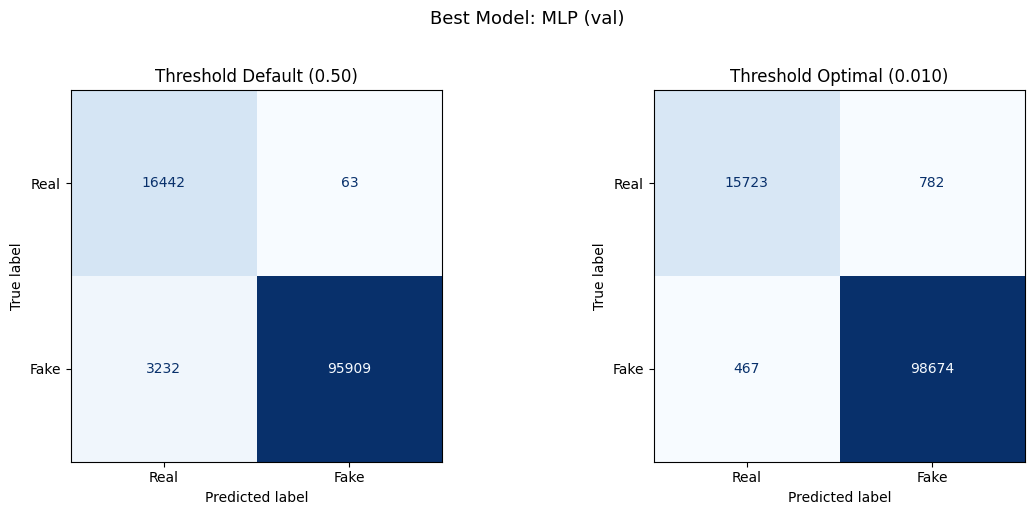

In [31]:
# ── Confusion matrices side by side ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, thr_label in zip(
    axes,
    [best_test_pred_default, best_test_pred_optimal],
    ['Default (0.50)', f'Optimal ({thr:.3f})']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Real', 'Fake'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Threshold {thr_label}', fontsize=12)
plt.suptitle(f'Best Model: {best_model_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

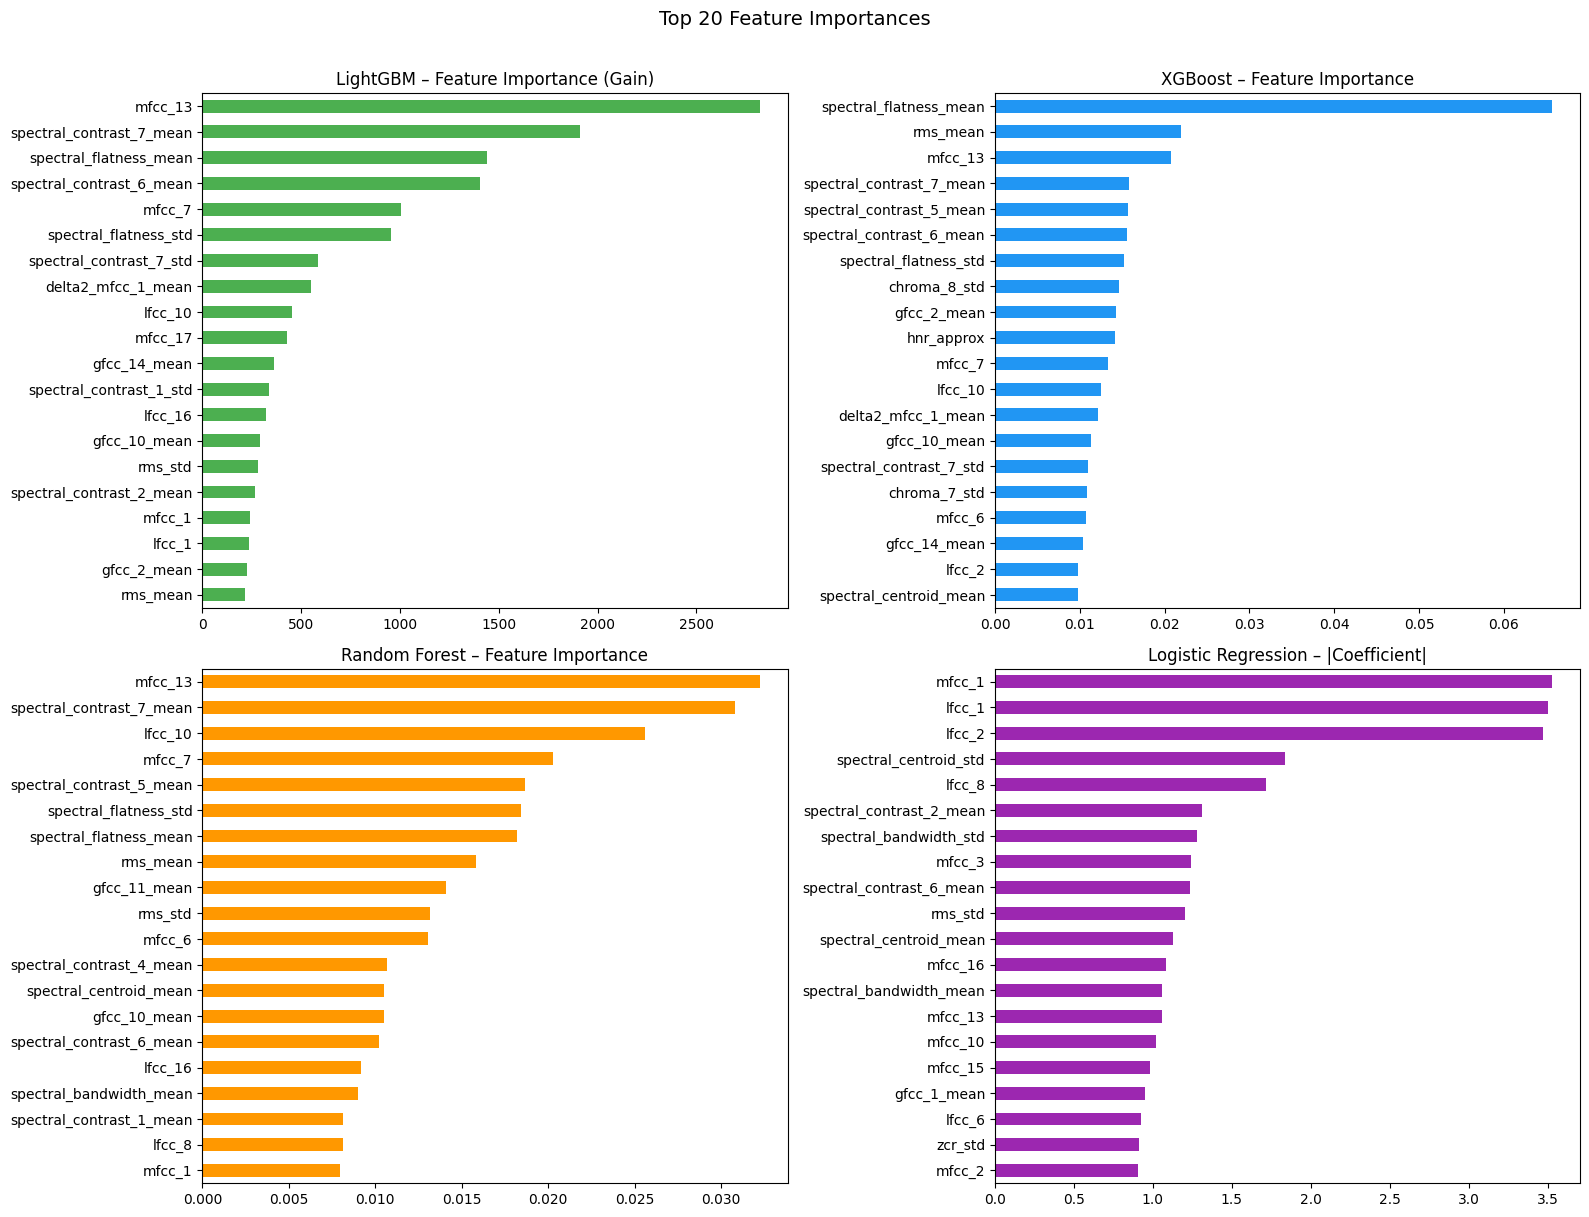

In [32]:
# ── Feature Importance (LightGBM / XGBoost / RF / LR, whichever available) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

top_n = 20

# LightGBM
lgb_fi = pd.Series(lgb_model.feature_importance('gain'),
                   index=feat_cols).nlargest(top_n)
lgb_fi.sort_values().plot(kind='barh', ax=axes[0], color='#4CAF50')
axes[0].set_title('LightGBM – Feature Importance (Gain)')

# XGBoost
xgb_fi = pd.Series(xgb_clf.feature_importances_,
                   index=feat_cols).nlargest(top_n)
xgb_fi.sort_values().plot(kind='barh', ax=axes[1], color='#2196F3')
axes[1].set_title('XGBoost – Feature Importance')

# Random Forest
rf_fi = pd.Series(rf.feature_importances_,
                  index=feat_cols).nlargest(top_n)
rf_fi.sort_values().plot(kind='barh', ax=axes[2], color='#FF9800')
axes[2].set_title('Random Forest – Feature Importance')

# Logistic Regression (abs coefficients)
lr_fi = pd.Series(np.abs(lr.coef_[0]),
                  index=feat_cols).nlargest(top_n)
lr_fi.sort_values().plot(kind='barh', ax=axes[3], color='#9C27B0')
axes[3].set_title('Logistic Regression – |Coefficient|')

plt.suptitle(f'Top {top_n} Feature Importances', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

## 11 · Final Leaderboard (Test Set)

Computing test metrics for all models …

=== FINAL TEST LEADERBOARD ===
                   Accuracy      F1 AUC_ROC  AUC_PR
MLP                  0.9715  0.9831  0.9990  0.9998
XGBoost              0.7878  0.8589  0.9794  0.9964
ExtraTrees           0.8949  0.9357  0.9685  0.9942
RandomForest         0.9035  0.9413  0.9684  0.9942
KNN                  0.7698  0.8464  0.9501  0.9882
LogisticRegression   0.8238  0.8889  0.9052  0.9813
LightGBM             0.3901  0.4507  0.7922  0.9539
GaussianNB           0.6861  0.7872  0.7640  0.9402


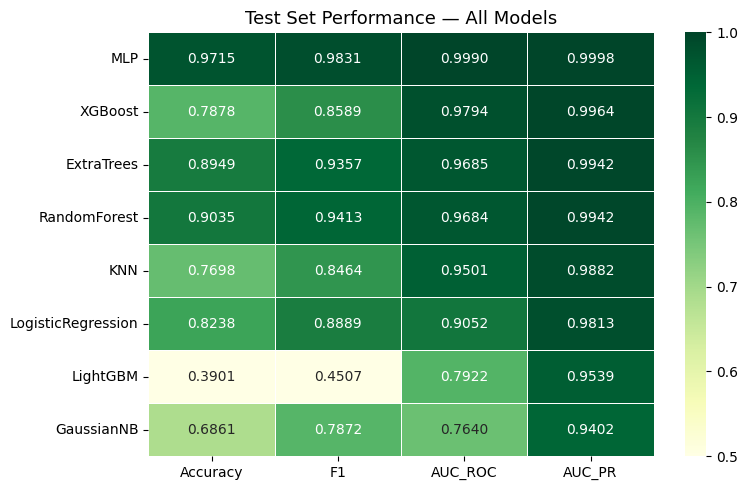


🏆 Best model on TEST SET: MLP  (AUC-ROC = 0.9990)


In [33]:
# Compute test metrics for ALL models
print('Computing test metrics for all models …')

test_probs = {
    'LogisticRegression': lr.predict_proba(X_test_s)[:, 1],
    'GaussianNB':         gnb.predict_proba(X_test_s)[:, 1],
    'KNN':                knn.predict_proba(X_test_s)[:, 1],
    'RandomForest':       rf.predict_proba(X_test_s)[:, 1],
    'ExtraTrees':         et.predict_proba(X_test_s)[:, 1],
    'XGBoost':            xgb_clf.predict_proba(X_test_s)[:, 1],
    'LightGBM':           lgb_model.predict(X_test_s),
    'MLP':                best_test_prob if best_model_name=='MLP (val)' else None
}

# MLP if not best
if test_probs['MLP'] is None:
    mlp.eval()
    with torch.no_grad():
        l = mlp(torch.from_numpy(X_test_s).float().to(DEVICE)).cpu().numpy()
    test_probs['MLP'] = torch.sigmoid(torch.tensor(l)).numpy()

test_results = {}
for name, prob in test_probs.items():
    pred = (prob >= 0.5).astype(int)
    test_results[name] = dict(
        Accuracy = accuracy_score(y_test, pred),
        F1       = f1_score(y_test, pred),
        AUC_ROC  = roc_auc_score(y_test, prob),
        AUC_PR   = average_precision_score(y_test, prob),
    )

test_lb = pd.DataFrame(test_results).T.sort_values('AUC_ROC', ascending=False)
print('\n=== FINAL TEST LEADERBOARD ===')
print(test_lb.map(lambda x: f'{x:.4f}').to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(test_lb, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title('Test Set Performance — All Models', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test_leaderboard_heatmap.png', dpi=120)
plt.show()

winner = test_lb['AUC_ROC'].idxmax()
print(f'\n🏆 Best model on TEST SET: {winner}  '
      f'(AUC-ROC = {test_lb.loc[winner, "AUC_ROC"]:.4f})')

## 12 · Save Summary Report

In [34]:
report_path = MODEL_DIR / 'experiment_summary.csv'
test_lb.reset_index().rename(columns={'index': 'Model'}).to_csv(report_path, index=False)
print(f'Experiment summary saved to {report_path}')

print('\n=== Saved Artifacts ===')
for p in sorted(MODEL_DIR.iterdir()):
    print(f'  {p.name}')
print('\n=== Saved Plots ===')
for p in sorted(PLOTS_DIR.iterdir()):
    print(f'  {p.name}')

print('\n✅ Pipeline complete!')

Experiment summary saved to /kaggle/working/models/experiment_summary.csv

=== Saved Artifacts ===
  clip_bounds.pkl
  experiment_summary.csv
  extra_trees.pkl
  knn.pkl
  lightgbm.txt
  logistic_regression.pkl
  mlp_best.pt
  naive_bayes.pkl
  optimal_threshold.pkl
  random_forest.pkl
  scaler.pkl
  stacking_ensemble.pkl
  xgboost.json

=== Saved Plots ===
  confusion_matrices.png
  eda_overview.png
  feature_importances.png
  mlp_training_curve.png
  model_comparison.png
  roc_curves.png
  test_leaderboard_heatmap.png

✅ Pipeline complete!
